# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| scikit-learn", sklearn.__version__)

python 3.13.15 | scikit-learn 1.6.1


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [ ]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
iris = pd.read_csv("../datasets/iris.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [3]:
def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'."""

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    errors = y_true - y_pred

    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(errors))

    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - ss_res / ss_tot

    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2)
    }

In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

**Your answer:**

_(replace this line)_

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [7]:
def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Confusion matrix cells
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    # Precision
    if tp + fp == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)

    # Recall
    if tp + fn == 0:
        recall = 0.0
    else:
        recall = tp / (tp + fn)

    # F1
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

In [8]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [9]:
def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline."""

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Find the majority class
    classes, counts = np.unique(y_true, return_counts=True)
    majority_class = classes[np.argmax(counts)]

    # Baseline: always predict the majority class
    baseline_predictions = np.full_like(y_true, majority_class)

    baseline_accuracy = np.mean(baseline_predictions == y_true)
    model_accuracy = np.mean(y_pred == y_true)

    improvement = model_accuracy - baseline_accuracy

    return {
        "majority_class": int(majority_class),
        "baseline_accuracy": float(baseline_accuracy),
        "model_accuracy": float(model_accuracy),
        "improvement": float(improvement)
    }

In [10]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [11]:
def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating."""

    # ---------------------------------------------------------
    # Leaky approach:
    # fit scaler on ALL data before cross-validation
    # ---------------------------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    leaky_model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=SEED
    )

    leaky_scores = cross_val_score(
        leaky_model,
        X_scaled,
        y,
        cv=cv,
        scoring="accuracy"
    )

    leaky = np.mean(leaky_scores)

    # ---------------------------------------------------------
    # Clean approach:
    # scaler is fitted separately inside each CV fold
    # ---------------------------------------------------------
    clean_estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            random_state=SEED
        ))
    ])

    clean_scores = cross_val_score(
        clean_estimator,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    clean = np.mean(clean_scores)

    difference = leaky - clean

    return {
        "leaky": float(leaky),
        "clean": float(clean),
        "difference": float(difference),
        "clean_estimator": clean_estimator
    }

In [12]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [14]:
# Space for the code that supports your answer.

**Your answer:**

_(replace this line)_

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [15]:
def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors."""

    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    results = []

    for d in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=d),
            LinearRegression()
        )

        # Fit on all data
        model.fit(x, y)

        # Training MSE
        y_pred = model.predict(x)
        train_mse = np.mean((y - y_pred) ** 2)

        # Cross-validation MSE
        cv_scores = cross_val_score(
            model,
            x,
            y,
            cv=cv,
            scoring="neg_mean_squared_error"
        )

        cv_mse = -np.mean(cv_scores)

        results.append({
            "degree": d,
            "train_mse": train_mse,
            "cv_mse": cv_mse
        })

    result = pd.DataFrame(results)
    result = result.set_index("degree")

    return result[["train_mse", "cv_mse"]]

In [16]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

        train_mse      cv_mse
degree                       
1        397.8800    468.4700
2        146.8600    165.9000
3        144.4100    168.8300
4         82.1600    111.8500
5         81.3900    120.0800
6         81.1400    128.5300
7         81.0700    157.3500
8         73.3200    113.4500
9         70.4200    115.2500
10        69.2800    118.8700
11        68.6700    171.4900
12        68.4400  1,699.0900
13        68.4400 19,405.7200
14        66.2600 91,266.7500
15        65.9500 28,992.7500

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

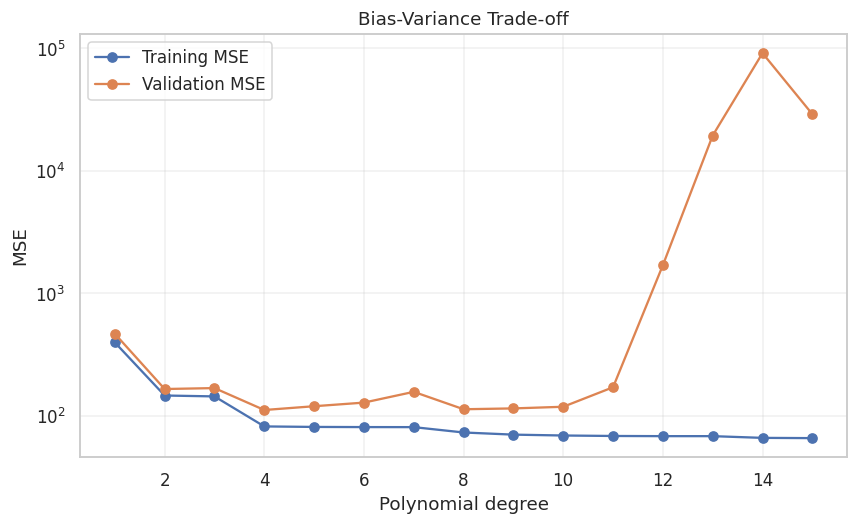

500-point sweep:
        train_mse   cv_mse
degree                    
1        339.2000 341.5000
2        176.1400 178.2000
3        176.1300 179.7500
4        137.2900 140.5000
5        136.8800 140.6700
6        136.5100 141.0200
7        136.2600 141.2000
8        136.1500 143.0700
9        136.0600 143.1600
10       135.6100 143.7200
11       135.4800 144.7600
12       135.4600 148.3100
13       135.4100 158.6400
14       135.4100 184.2100
15       134.8000 168.0900

Best degree with 50 points: 4
Best degree with 500 points: 4


In [17]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# (a) Plot training and CV MSE
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    _sweep.index,
    _sweep["train_mse"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    _sweep.index,
    _sweep["cv_mse"],
    marker="o",
    label="Validation MSE"
)

plt.yscale("log")

plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Bias-Variance Trade-off")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# ---------------------------------------------------------
# (c) Repeat with 500 points
# ---------------------------------------------------------

_poly_rng_500 = np.random.default_rng(SEED)

_x_poly_500 = _poly_rng_500.uniform(-3, 3, 500)

_y_poly_500 = (
    _x_poly_500 ** 4
    - 3 * _x_poly_500 ** 2
    + _x_poly_500
    + 5
    + _poly_rng_500.normal(0, 12.0, 500)
)

_sweep_500 = degree_sweep(
    _x_poly_500,
    _y_poly_500,
    range(1, 16),
    KFold(5, shuffle=True, random_state=SEED)
)

print("500-point sweep:")
print(_sweep_500.round(2).to_string())

print(
    "\nBest degree with 50 points:",
    _sweep["cv_mse"].idxmin()
)

print(
    "Best degree with 500 points:",
    _sweep_500["cv_mse"].idxmin()
)

**Your answer:**

**(a)**

At low polynomial degrees, the model is in the **underfitting region**. For example, at degree 1 the training MSE is about 339.20 and the validation MSE is about 341.50. Both errors are relatively high. As the degree increases, the training and validation errors initially decrease because the model becomes flexible enough to represent the nonlinear relationship in the data.

The **overfitting region** starts after the validation MSE reaches its minimum at degree 4. From this point, the training MSE continues to decrease as the polynomial becomes more flexible, while the validation MSE begins to increase. For example, with 500 observations, the training MSE decreases from 137.29 at degree 4 to 134.80 at degree 15, while the validation MSE increases from 140.50 to 168.09. This indicates that the additional flexibility is mainly fitting noise in the training data.

The gap between training and validation error is the important diagnostic rather than either curve alone. A low training MSE does not necessarily indicate good generalisation because a sufficiently flexible model can fit the training data very closely. Overfitting is indicated when training error continues to fall while validation error rises, causing an increasing gap between the two curves.

**(b)**

As the polynomial degree approaches the number of observations, the training MSE tends toward zero. A sufficiently high-degree polynomial has enough flexibility to interpolate the training observations almost exactly, including random noise.

The validation MSE does not tend toward zero. Instead, after reaching a minimum, it increases as the model becomes excessively complex. The high-degree polynomial becomes sensitive to the particular training sample and fits noise rather than the underlying relationship. Consequently, its predictions on unseen data become less reliable. This is the high-variance overfitting regime.

**(c)**

With 50 observations, the best degree according to cross-validation is **4**. With 500 observations, the best degree is also **4**.

For the 500-point dataset, the validation MSE is lowest at degree 4 (about 140.50). It then increases gradually for higher degrees and rises substantially at degrees 13–15. Thus, in this particular experiment, the additional data does not change the degree selected by cross-validation, but it makes the model substantially more resistant to overfitting. The increase in validation error at high degrees is delayed and is less severe than it would be with the smaller dataset.

In general, increasing the amount of training data allows a model with greater complexity to be estimated more reliably. More observations provide more information about the underlying relationship and reduce the variance of flexible models. Therefore, larger datasets generally allow greater model complexity before severe overfitting occurs.

Overall, the experiment demonstrates the bias-variance trade-off: models that are too simple have high bias and underfit, whereas excessively complex models have high variance and overfit. Cross-validation helps identify a degree that provides a suitable balance between these two sources of error.


## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
        'best_depth'      the chosen max_depth (may be None)
        'best_criterion'  the chosen criterion, a string
        'best_cv_score'   the best cross-validated accuracy, a float
        'search'          the fitted GridSearchCV object
    """

    model = DecisionTreeClassifier(random_state=SEED)

    param_grid = {
        "max_depth": list(depths),
        "criterion": list(criteria)
    }

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        refit=True
    )

    search.fit(X, y)

    return {
        "best_depth": search.best_params_["max_depth"],
        "best_criterion": search.best_params_["criterion"],
        "best_cv_score": float(search.best_score_),
        "search": search
    }

In [19]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [20]:
# (a) CV score for every max_depth and criterion
_results = pd.DataFrame(_tuned["search"].cv_results_)

_depth_table = _results.pivot(
    index="param_max_depth",
    columns="param_criterion",
    values="mean_test_score"
)

# Put depths in the requested order
_depth_order = [1, 2, 3, 4, 5, 6, 8, 10, None]

def depth_sort_key(x):
    if pd.isna(x):
        return 999
    return int(x)

_depth_table = _depth_table.sort_index(key=lambda s: s.map(depth_sort_key))

print("CV accuracy by max_depth and criterion:")
print(_depth_table.round(4).to_string())

# (c) Training accuracy of a fully grown tree
_full_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=SEED
)
_full_tree.fit(_X_iris, _y_iris)

_train_accuracy = _full_tree.score(_X_iris, _y_iris)

print(f"\nFully grown tree training accuracy: {_train_accuracy:.4f}")

# Useful for identifying the best depths
print("\nBest parameters:")
print(_tuned["search"].best_params_)
print(f"Best CV accuracy: {_tuned['search'].best_score_:.4f}")

CV accuracy by max_depth and criterion:
param_criterion  entropy   gini
param_max_depth                
1.0000            0.6667 0.6667
2.0000            0.9200 0.9200
3.0000            0.9200 0.9200
4.0000            0.9333 0.9333
5.0000            0.9333 0.9333
6.0000            0.9333 0.9333
8.0000            0.9333 0.9333
10.0000           0.9333 0.9333
NaN               0.9333 0.9333

Fully grown tree training accuracy: 1.0000

Best parameters:
{'criterion': 'gini', 'max_depth': 4}
Best CV accuracy: 0.9333


**Your answer:**

**(a)**

The CV results are:

| `max_depth` | `gini` | `entropy` |
| ----------: | -----: | --------: |
|           1 | 0.6667 |    0.6667 |
|           2 | 0.9200 |    0.9200 |
|           3 | 0.9200 |    0.9200 |
|           4 | 0.9333 |    0.9333 |
|           5 | 0.9333 |    0.9333 |
|           6 | 0.9333 |    0.9333 |
|           8 | 0.9333 |    0.9333 |
|          10 | 0.9333 |    0.9333 |
|        None | 0.9333 |    0.9333 |

The shallowest tree (`max_depth=1`) is clearly **underfitting**, because its CV accuracy is only 0.6667. Increasing the depth to 2 and then 4 substantially improves the CV accuracy.

For this dataset, the best CV accuracy is reached at `max_depth=4`. Increasing the depth beyond 4 does not improve the CV score. However, there is no further decrease in CV accuracy for depths 5 and above, so the results do not provide clear evidence of a distinct overfitting depth. Instead, they show that additional tree depth provides no cross-validation benefit.

Thus, underfitting is evident at very small depths, especially depth 1, while depths of 4 and above provide no additional CV improvement.

**(b)**

Gini impurity measures how mixed the classes are within a tree node. A value of zero means that all observations in the node belong to the same class.

Entropy measures class uncertainty using the Shannon entropy:

$$
H=-\sum_i p_i\log_2(p_i)
$$

Both criteria prefer splits that produce child nodes with purer class distributions. Therefore, they usually select similar splits and often produce nearly identical trees and CV scores.

They can disagree when several possible splits have very similar quality. Because Gini impurity and entropy use different mathematical functions to measure class impurity, they can rank such competing splits differently. This could result in different tree structures or slightly different validation scores.

In this experiment, both criteria produced exactly the same CV scores for every tested depth.

**(c)**

A fully grown tree with `max_depth=None` has a training accuracy of **1.0000**.

This number is uninformative because a fully grown tree can fit the training observations extremely closely, so perfect training accuracy does not demonstrate good generalisation to unseen data.

The same behaviour can be limited from another direction using the **`min_samples_leaf`** hyperparameter, which requires each leaf to contain at least a specified number of training observations.


## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [23]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.
    """

    k_values = list(k_values)

    cv_scores = []

    # 1. Evaluate every k using CV on training data only
    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        cv_scores.append(np.mean(scores))

    cv_scores = np.asarray(cv_scores)

    # 2. Choose k with highest CV score.
    # np.argmax returns the first occurrence, so ties choose the smallest k.
    best_index = np.argmax(cv_scores)
    best_k_cv = k_values[best_index]

    # 3. Refit the selected pipeline on ALL training data
    best_model = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=best_k_cv)
    )

    best_model.fit(X_train, y_train)

    # 4. Evaluate ONCE on the test set
    test_accuracy = best_model.score(X_test, y_test)

    # 5. For comparison only: peek at test set for every k
    test_scores = []

    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k)
        )

        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        test_scores.append(score)

    test_scores = np.asarray(test_scores)

    # np.argmax chooses the smallest k in case of a tie
    best_peeking_index = np.argmax(test_scores)
    best_k_peeking = k_values[best_peeking_index]
    peeking_accuracy = test_scores[best_peeking_index]

    return {
        "cv_scores": cv_scores,
        "best_k_cv": int(best_k_cv),
        "test_accuracy": float(test_accuracy),
        "best_k_peeking": int(best_k_peeking),
        "peeking_accuracy": float(peeking_accuracy)
    }

In [24]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

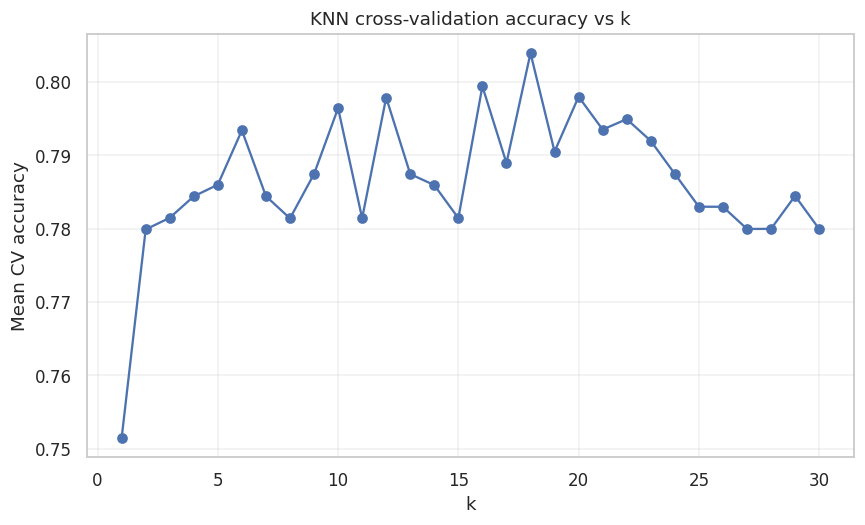

Sweep 1..30:
CV-selected k       = 18
Honest test accuracy = 0.8206
Peeking k           = 25
Peeking accuracy    = 0.8520
Optimism            = +0.0314

Sweep 1..200:
CV-selected k       = 18
Honest test accuracy = 0.8206
Peeking k           = 25
Peeking accuracy    = 0.8520
Optimism            = +0.0314

Test-size experiment:
test_size  train_size  test_n  best_k_cv honest_test_accuracy
     0.10         801      90         18               0.8333
     0.25         668     223         18               0.8206
     0.40         534     357          8               0.8095


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------
# (a) CV scores vs k
# -------------------------

_k_values_30 = list(range(1, 31))

plt.figure(figsize=(9, 5))
plt.plot(_k_values_30, _sel["cv_scores"], marker="o")
plt.xlabel("k")
plt.ylabel("Mean CV accuracy")
plt.title("KNN cross-validation accuracy vs k")
plt.grid(True, alpha=0.3)
plt.show()


# -------------------------
# (b) Compare k=1..30 vs k=1..200
# -------------------------

_k_values_200 = list(range(1, 201))

_sel_200 = honest_k_selection(
    _Xk_tr,
    _yk_tr,
    _Xk_te,
    _yk_te,
    _k_values_200,
    _k_cv
)

print("Sweep 1..30:")
print(f"CV-selected k       = {_sel['best_k_cv']}")
print(f"Honest test accuracy = {_sel['test_accuracy']:.4f}")
print(f"Peeking k           = {_sel['best_k_peeking']}")
print(f"Peeking accuracy    = {_sel['peeking_accuracy']:.4f}")
print(f"Optimism            = "
      f"{_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")

print("\nSweep 1..200:")
print(f"CV-selected k       = {_sel_200['best_k_cv']}")
print(f"Honest test accuracy = {_sel_200['test_accuracy']:.4f}")
print(f"Peeking k           = {_sel_200['best_k_peeking']}")
print(f"Peeking accuracy    = {_sel_200['peeking_accuracy']:.4f}")
print(f"Optimism            = "
      f"{_sel_200['peeking_accuracy'] - _sel_200['test_accuracy']:+.4f}")


# -------------------------
# (c) Different test sizes
# -------------------------

_test_size_results = []

for test_size in [0.1, 0.25, 0.4]:

    X_tr, X_te, y_tr, y_te = train_test_split(
        _X_knn,
        _y_knn,
        test_size=test_size,
        random_state=SEED,
        stratify=_y_knn
    )

    cv_result = honest_k_selection(
        X_tr,
        y_tr,
        X_te,
        y_te,
        range(1, 31),
        _k_cv
    )

    _test_size_results.append({
        "test_size": test_size,
        "train_size": len(X_tr),
        "test_n": len(X_te),
        "best_k_cv": cv_result["best_k_cv"],
        "honest_test_accuracy": cv_result["test_accuracy"]
    })

_test_size_table = pd.DataFrame(_test_size_results)

print("\nTest-size experiment:")
print(
    _test_size_table.to_string(
        index=False,
        formatters={
            "test_size": "{:.2f}".format,
            "honest_test_accuracy": "{:.4f}".format
        }
    )
)

**Your answer:**

**(a)**

The CV accuracy curve shows the typical bias-variance behaviour of KNN. The **small-k end is the overfitting region**, while the **large-k end is the underfitting region**.

At `k = 1`, each training observation is effectively its own nearest neighbour, so the training accuracy can reach 1.0. However, the model is very sensitive to individual observations and noise, so its validation accuracy can be substantially lower. This is the high-variance, overfitting regime.

As `k` increases, the prediction is based on more neighbours and becomes smoother and less sensitive to individual observations. At an intermediate value of `k`, the model achieves a better balance between bias and variance.

At `k = len(X_train)`, every prediction considers the entire training set as neighbours. Therefore, the model effectively predicts the majority class for all observations. The training accuracy and validation accuracy both approach the majority-class baseline rather than remaining high. This is the extreme underfitting regime.

**(b)**

For `k = 1..30`, cross-validation selected `k = 18`, giving an honest test accuracy of **0.8206**. If the test set was incorrectly used to choose `k`, the selected value was `k = 25`, with an apparent accuracy of **0.8520**. The resulting optimism was **+0.0314**.

The peeking number is biased upward because each test accuracy is a noisy measurement of the model's true generalisation performance. If we calculate the maximum

$$
\max(A_1,A_2,\ldots,A_k),
$$

we are selecting the most favourable random measurement among all tested models. Even when the measurement errors are centred around the true values, the maximum tends to be larger than the underlying value. Therefore, selecting a model based on test-set performance produces an optimistically biased estimate.

When the sweep was extended from `k = 1..30` to `k = 1..200`, the result was unchanged in this experiment:

* CV-selected `k`: **18**
* honest test accuracy: **0.8206**
* peeking `k`: **25**
* peeking accuracy: **0.8520**
* optimism: **+0.0314**

Thus, the optimism did **not increase in this particular experiment**. A larger search generally provides more opportunities to select an unusually favourable noisy measurement, so the potential for selection bias increases, but it does not guarantee a larger observed bias in every particular dataset and split.

**(c)**

The results for different test-set sizes were:

| Test size | Training observations | Test observations | CV-selected k | Honest test accuracy |
| --------: | --------------------: | ----------------: | ------------: | -------------------: |
|      0.10 |                   801 |                90 |            18 |               0.8333 |
|      0.25 |                   668 |               223 |            18 |               0.8206 |
|      0.40 |                   534 |               357 |             8 |               0.8095 |

When the test set grows, more observations are available for estimating the final test performance, so the test-set estimate generally becomes more stable. However, fewer observations remain for training the model. This can reduce the information available to the model and may result in lower predictive performance.

In this experiment, increasing `test_size` from 0.10 to 0.40 reduced the training set from 801 to 534 observations. The selected `k` also changed from 18 to 8, showing that changing the amount of training data can affect the hyperparameter selected by cross-validation.

The `stratify=_y_knn` argument protects against obtaining train and test sets with substantially different class proportions. It preserves approximately the same distribution of the target classes in both subsets as in the original dataset. Without stratification, a random split could contain an unusually high or low proportion of one class, making the measured accuracy less representative of the model's performance on the original population.


## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [26]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is  w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """

    scaler = pipeline.named_steps["standardscaler"]
    svc = pipeline.named_steps["svc"]

    w1, w2 = svc.coef_[0]
    b = svc.intercept_[0]

    if np.isclose(w2, 0.0):
        raise ValueError("w2 is zero: the boundary is vertical")

    mu_x, mu_y = scaler.mean_
    s_x, s_y = scaler.scale_

    slope = -(w1 * s_y) / (w2 * s_x)

    intercept = (
        mu_y
        + (s_y / w2) * ((w1 * mu_x / s_x) - b)
    )

    return float(slope), float(intercept)

In [27]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 1.60e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

In [28]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd

# ============================================================
# (a) Effect of C for the linear SVM
# ============================================================

_C_values = [0.001, 1, 1000]
_C_results = []

for C in _C_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=C, random_state=SEED)
    )

    model.fit(_X_two, _y_two)

    svc = model.named_steps["svc"]

    n_support = int(np.sum(svc.n_support_))
    margin_width = 2.0 / np.linalg.norm(svc.coef_)

    _C_results.append({
        "C": C,
        "support_vectors": n_support,
        "margin_width": margin_width
    })

_C_table = pd.DataFrame(_C_results)

print("Effect of C:")
print(
    _C_table.to_string(
        index=False,
        formatters={
            "margin_width": "{:.4f}".format
        }
    )
)


# ============================================================
# (b) RBF kernel: gamma sweep
# ============================================================

_gamma_values = [0.01, 1, 100]

_gamma_results = []

_gamma_cv = StratifiedKFold(
    5,
    shuffle=True,
    random_state=SEED
)

for gamma in _gamma_values:
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1,
            gamma=gamma,
            random_state=SEED
        )
    )

    scores = cross_val_score(
        model,
        _X_two,
        _y_two,
        cv=_gamma_cv,
        scoring="accuracy"
    )

    gamma_model = model.fit(_X_two, _y_two)
    svc = gamma_model.named_steps["svc"]

    _gamma_results.append({
        "gamma": gamma,
        "cv_accuracy": np.mean(scores),
        "support_vectors": int(np.sum(svc.n_support_))
    })

_gamma_table = pd.DataFrame(_gamma_results)

print("\nRBF gamma sweep:")
print(
    _gamma_table.to_string(
        index=False,
        formatters={
            "cv_accuracy": "{:.4f}".format
        }
    )
)

Effect of C:
         C  support_vectors margin_width
    0.0010              600       4.9368
    1.0000               74       0.4146
1,000.0000               46       0.2189

RBF gamma sweep:
   gamma cv_accuracy  support_vectors
  0.0100      0.9650              284
  1.0000      0.9683               86
100.0000      0.9550              487


**Your answer:**

**(a)**

The results for the linear SVM were:

|     C | Support vectors | Margin width |
| ----: | --------------: | -----------: |
| 0.001 |             600 |       4.9368 |
|     1 |              74 |       0.4146 |
|  1000 |              46 |       0.2189 |

A small `C` corresponds to a wide margin and allows the classifier to tolerate more training errors. Therefore, `C = 0.001` represents the **underfitting direction**. In this case, the margin is very wide (4.9368) and there are many support vectors (600).

As `C` increases, classification errors are penalised more strongly. The SVM therefore tries harder to classify the training observations correctly and produces a narrower margin. At `C = 1000`, the margin width has decreased to 0.2189 and there are only 46 support vectors.

Thus, increasing `C` makes the margin narrower and makes the classifier more sensitive to individual training observations. The large-`C` direction corresponds to greater model complexity and a higher risk of overfitting, while the small-`C` direction corresponds to stronger regularisation and underfitting.

**(b)**

The RBF results were:

| Gamma | CV accuracy | Support vectors |
| ----: | ----------: | --------------: |
|  0.01 |      0.9650 |             284 |
|     1 |      0.9683 |              86 |
|   100 |      0.9550 |             487 |

The `gamma` parameter controls the reach of an individual training point. With a small `gamma`, each point has a broad influence over the feature space. Therefore, at `gamma = 0.01`, the decision boundary is relatively smooth and the model has lower complexity.

At `gamma = 1`, the influence of individual observations is more local, allowing the classifier to model more detailed structure. In this experiment it gives the highest CV accuracy of 0.9683.

At very large `gamma`, each training observation has an extremely local influence. The boundary can become highly irregular and adapt to individual observations. At `gamma = 100`, there are 487 support vectors and the CV accuracy decreases to 0.9550. This is the high-variance, overfitting direction.

Therefore, the **large-gamma extreme (`gamma = 100`) is the one associated with memorisation**.

**(c)**

The RBF kernel does not meaningfully outperform the linear kernel for this dataset. The data are generated from two approximately linear class boundaries with noise, so a linear decision boundary already captures the main structure of the problem.

The RBF kernel is more flexible and can represent nonlinear decision boundaries. However, this additional flexibility is not necessary when the underlying relationship is essentially linear. In this experiment, the RBF CV accuracy at its best value (`gamma = 1`) is 0.9683, while the linear model is already capable of representing the main separation between the two classes.

The general principle is to choose a model and kernel with enough flexibility to represent the underlying structure of the problem, but avoid unnecessary complexity because excessive flexibility can increase variance and the risk of fitting noise rather than improving generalisation.


## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [29]:
def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
        'inertia'      KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
        'silhouette'   silhouette_score of that KMeans labelling
        'bic'          GaussianMixture(n_components=k, covariance_type='full',
                       random_state=SEED).bic(X)
        'aic'          the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    results = []

    for k in k_values:
        # K-Means
        kmeans = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=SEED
        )
        labels = kmeans.fit_predict(X)

        inertia = kmeans.inertia_
        silhouette = silhouette_score(X, labels)

        # Gaussian Mixture
        gmm = GaussianMixture(
            n_components=k,
            covariance_type="full",
            random_state=SEED
        )
        gmm.fit(X)

        bic = gmm.bic(X)
        aic = gmm.aic(X)

        results.append({
            "k": k,
            "inertia": inertia,
            "silhouette": silhouette,
            "bic": bic,
            "aic": aic
        })

    return pd.DataFrame(results).set_index("k")[
        ["inertia", "silhouette", "bic", "aic"]
    ]

In [30]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
k                                             
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [31]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

X_hard (900, 2)  true components: 3


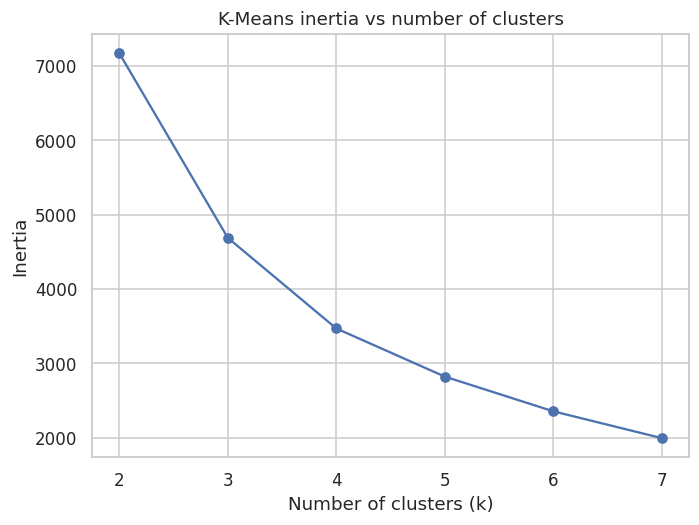

Cluster selection on harder data:
     inertia  silhouette        bic        aic
k                                             
2 7,175.0020      0.5160 8,512.4190 8,459.5920
3 4,690.2510      0.4230 8,410.6690 8,329.0280
4 3,470.1580      0.4280 8,451.9990 8,341.5440
5 2,822.5210      0.4040 8,490.5460 8,351.2760
6 2,355.3400      0.3660 8,526.4190 8,358.3360
7 1,994.2770      0.3680 8,559.2670 8,362.3680

Silhouette -> 2, BIC -> 3, AIC -> 3

K-Means with n_init=1:
 random_state  inertia
            0 4691.929
            1 4690.251
            2 4690.251
            3 4691.929
            4 4691.929
            5 4691.929
            6 4691.929
            7 4692.743
            8 4691.929
            9 4690.251

Inertia range: 4690.251 - 4692.743
Spread: 2.493

GMM covariance comparison:
covariance_type    ARI
           full 0.6407
           tied 0.4493
           diag 0.4362
      spherical 0.4527


In [32]:
# (a) Inertia for different numbers of clusters
_k_values = range(2, 8)

_inertia_values = []

for k in _k_values:
    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEED
    )
    km.fit(X_hard)
    _inertia_values.append(km.inertia_)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(list(_k_values), _inertia_values, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means inertia vs number of clusters")
plt.xticks(list(_k_values))
plt.grid(True)
plt.show()


# (b) Cluster selection on the harder data
_hard_scores = cluster_selection(X_hard, range(2, 8))

print("Cluster selection on harder data:")
print(_hard_scores.round(3).to_string())

print(
    f"\nSilhouette -> {_hard_scores['silhouette'].idxmax()}, "
    f"BIC -> {_hard_scores['bic'].idxmin()}, "
    f"AIC -> {_hard_scores['aic'].idxmin()}"
)


# (c) K-Means with n_init=1 and different random states
_single_init_results = []

for random_state in range(10):
    km = KMeans(
        n_clusters=3,
        n_init=1,
        random_state=random_state
    )
    km.fit(X_hard)

    _single_init_results.append({
        "random_state": random_state,
        "inertia": km.inertia_
    })

_single_init_table = pd.DataFrame(_single_init_results)

print("\nK-Means with n_init=1:")
print(
    _single_init_table.to_string(
        index=False,
        formatters={"inertia": "{:.3f}".format}
    )
)

print(
    f"\nInertia range: "
    f"{_single_init_table['inertia'].min():.3f} - "
    f"{_single_init_table['inertia'].max():.3f}"
)

print(
    f"Spread: "
    f"{_single_init_table['inertia'].max() - _single_init_table['inertia'].min():.3f}"
)


# (d) GMM with different covariance assumptions
_covariance_results = []

for covariance_type in ("full", "tied", "diag", "spherical"):
    gmm = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=SEED
    )
    gmm.fit(X_hard)

    labels = gmm.predict(X_hard)
    ari = adjusted_rand_score(y_hard, labels)

    _covariance_results.append({
        "covariance_type": covariance_type,
        "ARI": ari
    })

_covariance_table = pd.DataFrame(_covariance_results)

print("\nGMM covariance comparison:")
print(
    _covariance_table.to_string(
        index=False,
        formatters={"ARI": "{:.4f}".format}
    )
)

**Your answer:**

**(a)**

The inertia decreases as the number of clusters increases:

|  k |  Inertia |
| -: | -------: |
|  2 | 7175.002 |
|  3 | 4690.251 |
|  4 | 3470.158 |
|  5 | 2822.521 |
|  6 | 2355.340 |
|  7 | 1994.277 |

Inertia cannot simply be minimised to choose `k` because it always decreases as more clusters are added. With a sufficiently large number of clusters, K-Means can make the clusters smaller and reduce the within-cluster sum of squared distances.

The **elbow** is the point where increasing the number of clusters starts to produce substantially smaller improvements in inertia. It is intended to represent a reasonable trade-off between cluster compactness and model complexity.

In this plot, the elbow is not completely sharp. There is a large reduction from `k=2` to `k=3`, followed by smaller improvements. Therefore, I would not claim to identify the elbow with very high confidence from this plot alone.

**(b)**

For the harder data, the results are:

|  k |  Inertia | Silhouette |      BIC |      AIC |
| -: | -------: | ---------: | -------: | -------: |
|  2 | 7175.002 |      0.516 | 8512.419 | 8459.592 |
|  3 | 4690.251 |      0.423 | 8410.669 | 8329.028 |
|  4 | 3470.158 |      0.428 | 8451.999 | 8341.544 |
|  5 | 2822.521 |      0.404 | 8490.546 | 8351.276 |
|  6 | 2355.340 |      0.366 | 8526.419 | 8358.336 |
|  7 | 1994.277 |      0.368 | 8559.267 | 8362.368 |

The silhouette criterion selects **k = 2**, while BIC selects **k = 3**. Since the data were generated from three underlying Gaussian components, **k = 3 is the appropriate choice for these data**.

The disagreement occurs because silhouette measures how well observations fit their assigned clusters based primarily on distances: it favours clusters that are compact internally and well separated from other clusters. Two of the components in these data overlap, and the components are tilted and have different covariance structures. As a result, combining overlapping components into two larger groups can produce a higher average silhouette score, even though the data were generated from three components.

BIC evaluates a probabilistic Gaussian-mixture model and penalises model complexity. A Gaussian mixture with full covariance matrices can represent tilted and differently shaped components, so BIC can identify the three underlying components more appropriately in this case.

**(c)**

With `n_init=1` and ten different random states, the observed inertia values were:

| Random state |  Inertia |
| -----------: | -------: |
|            0 | 4691.929 |
|            1 | 4690.251 |
|            2 | 4690.251 |
|            3 | 4691.929 |
|            4 | 4691.929 |
|            5 | 4691.929 |
|            6 | 4691.929 |
|            7 | 4692.743 |
|            8 | 4691.929 |
|            9 | 4690.251 |

The inertia ranged from **4690.251 to 4692.743**, giving a spread of:

**4692.743 − 4690.251 = 2.493**

Thus, different initialisations produced slightly different K-Means solutions.

The `n_init` parameter specifies how many different initial centroid configurations are tried. K-Means can converge to different local solutions depending on the starting centroids. Increasing `n_init` gives the algorithm several opportunities to find a better solution, and the result with the lowest inertia is retained.

The default `init='k-means++'` does not simply choose all initial centroids uniformly at random. Instead, it selects initial centroids in a way that tends to spread them across the data. This usually provides better starting points and makes the K-Means result more reliable.

**(d)**

The adjusted Rand index (ARI) for the different GMM covariance assumptions was:

| Covariance type |    ARI |
| --------------- | -----: |
| full            | 0.6407 |
| tied            | 0.4493 |
| diag            | 0.4362 |
| spherical       | 0.4527 |

The covariance assumptions are:

* **full** — each component has its own unrestricted covariance matrix. It can represent clusters with different sizes, orientations and elliptical shapes.
* **tied** — all components share the same full covariance matrix. The means can differ, but the covariance structure is common to all components.
* **diag** — each component has its own diagonal covariance matrix. Feature covariances are assumed to be zero, so arbitrary cluster tilting cannot be represented.
* **spherical** — each component has a single variance value, producing spherical clusters.

The **spherical** covariance assumption most closely reproduces the behaviour of K-Means. K-Means can be viewed as a limiting/special case of a Gaussian-mixture model with spherical clusters of equal variance and hard assignments.

For these data, the `full` covariance model achieves the highest ARI, **0.6407**. This is consistent with the structure of the generated data: the components have different covariance matrices and some are tilted. A full covariance matrix can represent these differences, whereas the other assumptions impose stronger restrictions on cluster shape.


## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

In [ ]:
# Your analysis. Add as many cells as you need.

**Your write-up:**

_(replace this line)_

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.